C:\Users\Merge\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


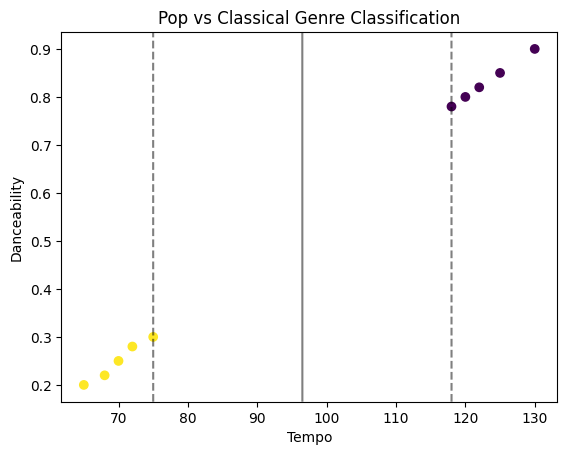

In [1]:
#Task 1: Music Genre Classification (Pop vs Classical)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Sample Dataset
data = {
    'tempo':[120,125,130,118,122,65,70,75,68,72],
    'danceability':[0.8,0.85,0.9,0.78,0.82,0.2,0.25,0.3,0.22,0.28],
    'genre':['Pop','Pop','Pop','Pop','Pop',
             'Classical','Classical','Classical',
             'Classical','Classical']
}

df = pd.DataFrame(data)

X = df[['tempo','danceability']]
y = df['genre']

# Train SVM
model = SVC(kernel='linear')
model.fit(X,y)

# Plot Decision Boundary
plt.scatter(
    df['tempo'],
    df['danceability'],
    c=[0 if g=="Pop" else 1 for g in y]
)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

plt.contour(
    XX,YY,Z,
    colors='k',
    levels=[-1,0,1],
    alpha=0.5,
    linestyles=['--','-','--']
)

plt.xlabel("Tempo")
plt.ylabel("Danceability")
plt.title("Pop vs Classical Genre Classification")
plt.show()

In [2]:
#Task 2: Flipkart Review Sentiment Classification
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = {
    'review':[
        'Excellent product',
        'Very good quality',
        'Loved it',
        'Amazing phone',
        'Worth buying',
        'Bad quality',
        'Waste of money',
        'Not good',
        'Poor product',
        'Terrible experience'
    ],
    'sentiment':[
        'Positive','Positive','Positive',
        'Positive','Positive',
        'Negative','Negative','Negative',
        'Negative','Negative'
    ]
}

df = pd.DataFrame(data)

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['review'])
y = df['sentiment']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = SVC(kernel='linear')

model.fit(X_train,y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)

print("Accuracy:",accuracy)

Accuracy: 0.0


In [ ]:
#Task 3: IPL Player Performance Classification
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Sample IPL Dataset
data = {
    'runs':[500,600,450,700,300,250,650,720,280,550],
    'strike_rate':[140,150,130,160,110,105,145,165,115,138],
    'performance':[1,1,1,1,0,0,1,1,0,1]
}

df = pd.DataFrame(data)

X = df[['runs','strike_rate']]
y = df['performance']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# Polynomial Kernel
poly_model = SVC(kernel='poly',degree=3)

poly_model.fit(X_train,y_train)

poly_pred = poly_model.predict(X_test)

poly_acc = accuracy_score(y_test,poly_pred)

# RBF Kernel
rbf_model = SVC(kernel='rbf')

rbf_model.fit(X_train,y_train)

rbf_pred = rbf_model.predict(X_test)

rbf_acc = accuracy_score(y_test,rbf_pred)

print("Polynomial Accuracy:",poly_acc)
print("RBF Accuracy:",rbf_acc)

Polynomial Accuracy: 1.0
RBF Accuracy: 1.0


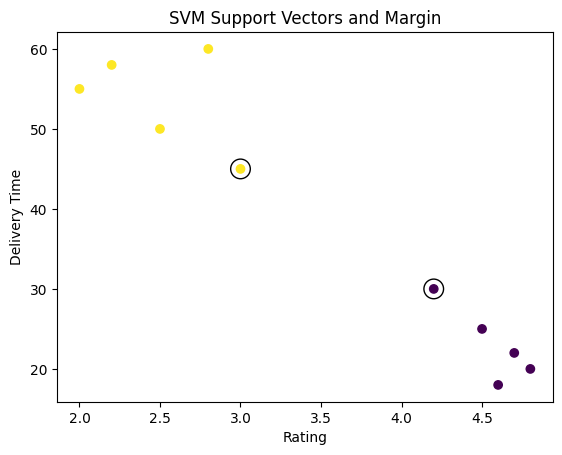

Support Vectors:
[[ 3.  45. ]
 [ 4.2 30. ]]


In [4]:
#Task 4: Zomato Restaurant Rating Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Sample Dataset
data = {
    'rating':[4.8,4.5,4.2,4.7,4.6,2.0,2.5,3.0,2.8,2.2],
    'delivery_time':[20,25,30,22,18,55,50,45,60,58],
    'label':['Good','Good','Good','Good','Good',
             'Bad','Bad','Bad','Bad','Bad']
}

df = pd.DataFrame(data)

X = df[['rating','delivery_time']]
y = df['label']

model = SVC(kernel='linear')

model.fit(X,y)

plt.scatter(
    X['rating'],
    X['delivery_time'],
    c=[0 if i=="Good" else 1 for i in y]
)

# Support Vectors
plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=200,
    facecolors='none',
    edgecolors='k'
)

plt.xlabel("Rating")
plt.ylabel("Delivery Time")
plt.title("SVM Support Vectors and Margin")
plt.show()

print("Support Vectors:")
print(model.support_vectors_)